In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [7]:
corpus = pd.read_csv("../data/output/CORPUS.csv", sep="|")
vocab = pd.read_csv("../data/output/VOCAB.csv", sep="|")
lib = pd.read_csv("../data/output/LIB.csv", sep="|")

print("Corpus:", corpus.shape)
print("Vocab:", vocab.shape)
print("LIB:", lib.shape)

Corpus: (789668, 8)
Vocab: (12878, 9)
LIB: (66, 11)


In [8]:
nrc_path = "/Users/nicholasthornton/Downloads/DS 5001/DS-5001-Bible-Analysis-Final-Project/data/archive/NRC-Emotion-Lexicon/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt"

nrc_raw = pd.read_csv(
    nrc_path,
    sep="\t",
    header=None,
    names=["term_str", "emotion", "association"]
)

nrc = (
    nrc_raw
    .pivot(index="term_str", columns="emotion", values="association")
    .fillna(0)
)

emo_cols = [
    "anger", "anticipation", "disgust", "fear",
    "joy", "sadness", "surprise", "trust",
    "positive", "negative"
]

print("NRC shape:", nrc.shape)
nrc.head()

NRC shape: (14154, 10)


emotion,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust
term_str,,,,,,,,,,
NaN,0,0,0,0,0,0,0,0,0,0
aback,0,0,0,0,0,0,0,0,0,0
abacus,0,0,0,0,0,0,0,0,0,1
abandon,0,0,0,1,0,1,0,1,0,0
abandoned,1,0,0,1,0,1,0,1,0,0


In [9]:
vocab_sent = (
    vocab
    .merge(
        nrc[emo_cols],
        left_on="term_str",
        right_index=True,
        how="left"
    )
)

vocab_sent[emo_cols] = vocab_sent[emo_cols].fillna(0)

print("Vocab with sentiment:", vocab_sent.shape)
vocab_sent.head()

Vocab with sentiment: (12878, 19)


,term_str,n,p,i,df,dfidf,max_pos,max_pos_group,stop,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,positive,negative
0,a,8177,0.010355,6.593531,6216,40985.387317,DT,OTHER,True,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,aaron,319,0.000404,11.273474,303,3415.862649,NN,NOUN,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,aaron's,31,0.000039,14.636690,31,453.737402,NN,NOUN,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,aaronites,2,0.000003,18.590887,2,37.181773,NNS,NOUN,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,abaddon,1,0.000001,19.590887,1,19.590887,NN,NOUN,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
corpus_sent = (
    corpus
    .merge(
        vocab_sent[["term_str"] + emo_cols],
        on="term_str",
        how="left"
    )
)

corpus_sent[emo_cols] = corpus_sent[emo_cols].fillna(0)

print("Corpus with sentiment:", corpus_sent.shape)
corpus_sent.head()

Corpus with sentiment: (789668, 18)


,book_number,chapter,verse,token_id,token_str,term_str,pos,pos_group,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,positive,negative
0,1,1,1,1,in,in,IN,OTHER,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,1,1,2,the,the,DT,OTHER,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,1,1,3,beginning,beginning,VBG,VERB,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,1,1,4,god,god,NN,NOUN,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
4,1,1,1,5,created,created,VBN,VERB,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
book_sentiment = (
    corpus_sent
    .groupby("book_number")[emo_cols]
    .mean()
    .reset_index()
    .merge(
        lib[["book_number", "book_name", "testament"]],
        on="book_number",
        how="left"
    )
)

book_sentiment.head()

,book_number,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,positive,negative,book_name,testament
0,1,0.009380,0.019805,0.011209,0.018133,0.023463,0.010791,0.007420,0.037572,0.049095,0.024012,Genesis,Old Testament
1,2,0.011595,0.016307,0.018173,0.017469,0.012880,0.010249,0.004773,0.036805,0.048859,0.032216,Exodus,Old Testament
2,3,0.016579,0.012872,0.041183,0.025296,0.015316,0.021060,0.005784,0.049778,0.058455,0.052996,Leviticus,Old Testament
3,4,0.011369,0.015747,0.023255,0.017510,0.013071,0.012980,0.006353,0.045568,0.049884,0.035019,Numbers,Old Testament
4,5,0.015731,0.029064,0.029346,0.031992,0.029100,0.014109,0.008007,0.057141,0.071779,0.047547,Deuteronomy,Old Testament


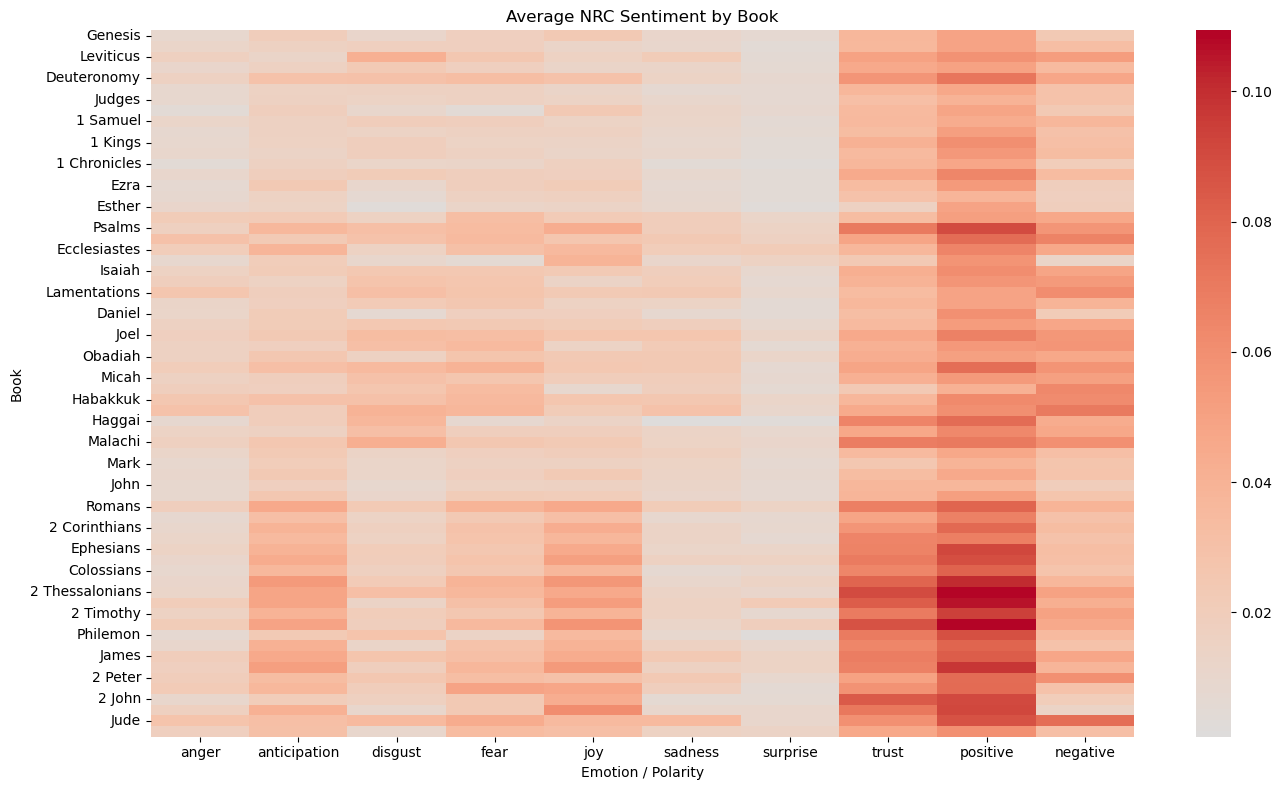

In [12]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    book_sentiment.set_index("book_name")[emo_cols],
    cmap="coolwarm",
    center=0
)

plt.title("Average NRC Sentiment by Book")
plt.ylabel("Book")
plt.xlabel("Emotion / Polarity")
plt.tight_layout()
plt.show()

In [14]:
ot_nt_means = (
    book_sentiment
    .groupby("testament")[emo_cols]
    .mean()
)

print("OT vs NT Mean Sentiment Scores:")
display(ot_nt_means)

OT vs NT Mean Sentiment Scores:


,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,positive,negative
testament,,,,,,,,,,
New Testament,0.014136,0.036153,0.018327,0.028607,0.039277,0.014922,0.010607,0.061374,0.078661,0.035558
Old Testament,0.014507,0.020401,0.022589,0.022940,0.020190,0.015289,0.008227,0.040420,0.057061,0.041785


In [16]:
difference = (
    ot_nt_means.loc["New Testament"] -
    ot_nt_means.loc["Old Testament"]
)

print("Difference (NT minus OT):")
display(difference.sort_values(ascending=False))

Difference (NT minus OT):


positive        0.021600
trust           0.020954
joy             0.019087
anticipation    0.015752
fear            0.005666
surprise        0.002380
sadness        -0.000367
anger          -0.000371
disgust        -0.004261
negative       -0.006226
dtype: float64

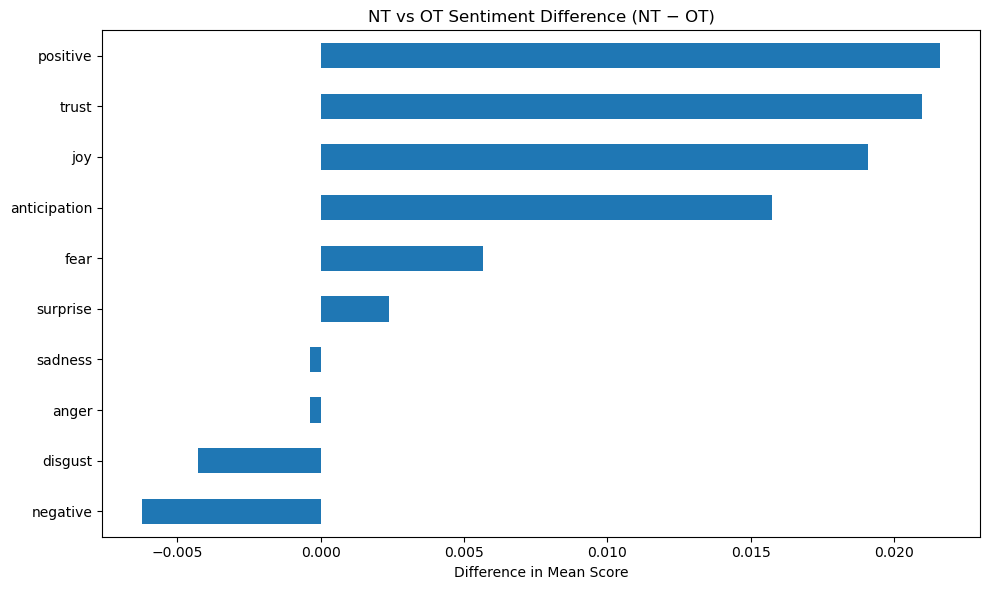

In [17]:
plt.figure(figsize=(10,6))

difference.sort_values().plot(kind="barh")

plt.title("NT vs OT Sentiment Difference (NT − OT)")
plt.xlabel("Difference in Mean Score")
plt.tight_layout()
plt.show()

In [13]:
output_path = "../data/output/VOCAB_SENTIMENT_BY_BOOK.csv"

book_sentiment.to_csv(output_path, index=False)

print("Saved:", output_path)

Saved: ../data/output/VOCAB_SENTIMENT_BY_BOOK.csv
